# 03-1. LightGBM モデル設計 — 2026-03-08

## リクルート飲食店来客数予測コンペティション

**目的**: 02で確定した特徴量セットと前提条件を使い、LightGBMモデルを構築・チューニングする。

### 本ノートブックの構成
1. データ読み込み（中間データから）
2. モデル概要と選定理由
3. ハイパーパラメータ設定（初期値）
4. 時系列バリデーションによる学習
5. 予測結果の分析
6. 特徴量重要度の分析
7. 残差分析
8. ハイパーパラメータチューニング（Optuna）
9. まとめと次ステップ

---
## 1. データ読み込み（中間データから）

02ノートブックで保存した `02_feature_design.pkl` を読み込み、特徴量の再計算を省略する。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['font.family'] = 'MS Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12
plt.rcParams['figure.facecolor'] = 'white'

SEED = 42
np.random.seed(SEED)
INTERMEDIATE_DIR = Path('./intermediate')

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

# 中間データの読み込み
with open(INTERMEDIATE_DIR / '02_feature_design.pkl', 'rb') as f:
    prev = pickle.load(f)

train_df = prev['train_features']
valid_df = prev['valid_features']
all_features = prev['feature_columns']['all_features']
scores_02 = prev['scores']
VALID_START = prev['VALID_START']

# 02で確定した前提条件を適用
settings = prev['confirmed_settings']
TRAIN_START = settings['best_train_start']
NAN_STRATEGY = settings['best_nan_strategy']

# 01 EDAで設計したval_folds（5フォールド時系列CV）を読み込み
val_folds = prev['val_folds']
print(f'  CV戦略: {len(val_folds)}フォールド時系列CV（01 EDA設計）')
for i, fold in enumerate(val_folds):
    print(f'    Fold {i+1}: val_start={fold["val_start"]}, val_end={fold["val_end"]}')

# 学習データ期間のフィルタリング
train_df = train_df[train_df['visit_date'] >= TRAIN_START].copy()

print('\n中間データ読み込み完了')
print(f'  学習データ: {train_df.shape} (期間: {TRAIN_START}～)')
print(f'  検証データ: {valid_df.shape}')
print(f'  特徴量数: {len(all_features)}')
print(f'\n=== 02で確定した前提条件 ===')
print(f'  学習データ期間: {settings["best_train_period"]} (start={TRAIN_START})')
print(f'  NaN処理: {NAN_STRATEGY}')
print(f'  Rolling構成: {settings["best_rolling_config"]}')
print(f'\n02での最終スコア（参考）: RMSLE = {scores_02["score_all"]:.5f}')

  CV戦略: 5フォールド時系列CV（01 EDA設計）
    Fold 1: val_start=2016-04-23, val_end=2016-05-31
    Fold 2: val_start=2016-07-16, val_end=2016-08-23
    Fold 3: val_start=2016-10-15, val_end=2016-11-22
    Fold 4: val_start=2016-12-16, val_end=2017-01-23
    Fold 5: val_start=2017-03-15, val_end=2017-04-22

中間データ読み込み完了
  学習データ: (222073, 60) (期間: 2015-12-12～)
  検証データ: (30035, 60)
  特徴量数: 53

=== 02で確定した前提条件 ===
  学習データ期間: 直近15ヶ月 (start=2015-12-12)
  NaN処理: NaN(デフォルト)
  Rolling構成: 現行のみ

02での最終スコア（参考）: RMSLE = 0.51636


---
## 2. モデル概要と選定理由

### LightGBMを最初のモデルとして選ぶ理由

| 理由 | 詳細 |
|------|------|
| 高速な学習 | Histogram-based splittingにより大規模データでも高速 |
| 欠損値処理 | NaN（ラグ特徴量の初期値等）を自動的に処理 |
| カテゴリ変数 | Optimal split for categoricalを内蔵 |
| 上位解法での実績 | このコンペの上位解法の大半がLightGBMを使用 |
| チューニングの容易さ | 少ないパラメータで十分な性能を発揮 |

### 学習方針
- 目的変数: `log1p(visitors)` → RMSEで学習 = RMSLE最適化と等価
- 検証: 時系列分割（未来のデータで評価）

---
## 3. ハイパーパラメータ設定

### パラメータの選定根拠

| パラメータ | 値 | 根拠 |
|-----------|-----|------|
| `num_leaves` | 63 | 中規模の木（デフォルト31より表現力を高める） |
| `learning_rate` | 0.02 | 低めに設定し、多くのイテレーションで精度を稼ぐ |
| `n_estimators` | 2000 | early_stoppingで自動決定するため大きめに設定 |
| `subsample` | 0.8 | 過学習抑制（全データの80%で各木を学習） |
| `colsample_bytree` | 0.8 | 特徴量のランダム選択で過学習抑制 |
| `min_child_samples` | 20 | リーフの最小サンプル数（過学習防止） |
| `reg_alpha` | 0.1 | L1正則化 |
| `reg_lambda` | 0.1 | L2正則化 |

In [2]:
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 63,
    'learning_rate': 0.02,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_samples': 20,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': SEED,
    'verbose': -1,
    'n_jobs': -1,
}

print('=== LightGBM ハイパーパラメータ ===')
for k, v in lgb_params.items():
    print(f'  {k}: {v}')

=== LightGBM ハイパーパラメータ ===
  objective: regression
  metric: rmse
  boosting_type: gbdt
  num_leaves: 63
  learning_rate: 0.02
  subsample: 0.8
  colsample_bytree: 0.8
  min_child_samples: 20
  reg_alpha: 0.1
  reg_lambda: 0.1
  random_state: 42
  verbose: -1
  n_jobs: -1


---
## 4. 時系列バリデーションによる学習

### バリデーション戦略

時系列データのため、**未来をリークしない分割**が必須。

- **Single split**: 学習 (～2017/3/11) → 検証 (2017/3/12～)
- **TimeSeriesSplit (3-fold)**: 時系列に沿った3分割でCV

まずSingle splitで学習し、次にCVで安定性を確認する。

In [3]:
# === Single Split での学習 ===
X_train = train_df[all_features]
y_train = np.log1p(train_df['visitors'])
X_valid = valid_df[all_features]
y_valid = np.log1p(valid_df['visitors'])

dtrain = lgb.Dataset(X_train, label=y_train)
dvalid = lgb.Dataset(X_valid, label=y_valid, reference=dtrain)

callbacks = [
    lgb.early_stopping(stopping_rounds=100, verbose=True),
    lgb.log_evaluation(period=200),
]

model = lgb.train(
    lgb_params,
    dtrain,
    num_boost_round=2000,
    valid_sets=[dtrain, dvalid],
    valid_names=['train', 'valid'],
    callbacks=callbacks,
)

# 予測
pred_log = model.predict(X_valid)
pred = np.expm1(pred_log)
score_single = rmsle(valid_df['visitors'], pred)

print(f'\n=== Single Split 結果 ===')
print(f'  Best iteration: {model.best_iteration}')
print(f'  RMSLE: {score_single:.5f}')
print(f'  02での簡易モデルスコア: {scores_02["score_all"]:.5f}')
print(f'  改善幅: {scores_02["score_all"] - score_single:.5f}')

Training until validation scores don't improve for 100 rounds
[200]	train's rmse: 0.490149	valid's rmse: 0.524718
[400]	train's rmse: 0.478664	valid's rmse: 0.519189
[600]	train's rmse: 0.471559	valid's rmse: 0.518099
[800]	train's rmse: 0.465352	valid's rmse: 0.517403
[1000]	train's rmse: 0.459698	valid's rmse: 0.517039
[1200]	train's rmse: 0.454441	valid's rmse: 0.516382
[1400]	train's rmse: 0.449502	valid's rmse: 0.516336
[1600]	train's rmse: 0.444752	valid's rmse: 0.516186
Early stopping, best iteration is:
[1595]	train's rmse: 0.444856	valid's rmse: 0.516154

=== Single Split 結果 ===
  Best iteration: 1595
  RMSLE: 0.51615
  02での簡易モデルスコア: 0.51636
  改善幅: 0.00020


In [4]:
# === 時系列 Cross-Validation（01 EDAで設計した5フォールド） ===
# ※ TimeSeriesSplit ではなく、02で検証済みのval_foldsを使用（スコア比較可能性を担保）
full_df = pd.concat([train_df, valid_df], ignore_index=True).sort_values('visit_date').reset_index(drop=True)

cv_scores = []
cv_models = []

for i, fold in enumerate(val_folds, 1):
    val_start = pd.Timestamp(fold['val_start'])
    val_end = pd.Timestamp(fold['val_end'])
    
    train_mask = full_df['visit_date'] < val_start
    valid_mask = (full_df['visit_date'] >= val_start) & (full_df['visit_date'] <= val_end)
    
    # 学習期間フィルタ（best_train_startと同等のロジック）
    fold_train = full_df[train_mask]
    fold_valid = full_df[valid_mask]
    
    if len(fold_train) == 0 or len(fold_valid) == 0:
        print(f'Fold {i}: スキップ（データ不足）')
        continue
    
    X_tr = fold_train[all_features]
    y_tr = np.log1p(fold_train['visitors'])
    X_va = fold_valid[all_features]
    y_va_raw = fold_valid['visitors']
    
    dtr = lgb.Dataset(X_tr, label=y_tr)
    dva = lgb.Dataset(X_va, label=np.log1p(y_va_raw), reference=dtr)
    
    m = lgb.train(
        lgb_params, dtr, num_boost_round=2000,
        valid_sets=[dva], valid_names=['valid'],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )
    
    p = np.expm1(m.predict(X_va))
    s = rmsle(y_va_raw, p)
    cv_scores.append(s)
    cv_models.append(m)
    
    print(f'Fold {i}: RMSLE={s:.5f}  '
          f'(train: {fold_train["visit_date"].min().date()}~{fold_train["visit_date"].max().date()}, '
          f'valid: {fold["val_start"]}~{fold["val_end"]}, '
          f'n_train={len(fold_train):,}, n_valid={len(fold_valid):,}, '
          f'best_iter={m.best_iteration})')

print(f'\n=== CV結果（5フォールド） ===')
print(f'  平均 RMSLE: {np.mean(cv_scores):.5f} (+/- {np.std(cv_scores):.5f})')
print(f'  各Fold: {[f"{s:.5f}" for s in cv_scores]}')

Fold 1: RMSLE=0.51978  (train: 2016-01-01~2016-04-22, valid: 2016-04-23~2016-05-31, n_train=29,116, n_valid=10,336, best_iter=204)
Fold 2: RMSLE=0.51009  (train: 2016-01-01~2016-07-15, valid: 2016-07-16~2016-08-23, n_train=58,174, n_valid=26,084, best_iter=244)
Fold 3: RMSLE=0.49293  (train: 2016-01-01~2016-10-14, valid: 2016-10-15~2016-11-22, n_train=120,279, n_valid=27,168, best_iter=313)
Fold 4: RMSLE=0.54166  (train: 2016-01-01~2016-12-15, valid: 2016-12-16~2017-01-23, n_train=163,715, n_valid=24,817, best_iter=682)
Fold 5: RMSLE=0.50311  (train: 2016-01-01~2017-03-14, valid: 2017-03-15~2017-04-22, n_train=224,077, n_valid=28,031, best_iter=1124)

=== CV結果（5フォールド） ===
  平均 RMSLE: 0.51352 (+/- 0.01658)
  各Fold: ['0.51978', '0.51009', '0.49293', '0.54166', '0.50311']


In [5]:
# === ルールベースベースライン: 店舗×曜日の過去中央値 ===
# 上位解法の知見: store×DOW中央値はGBDTに匹敵し、アンサンブルで補完効果がある
train_df_with_dow = train_df.copy()
train_df_with_dow['dow'] = train_df_with_dow['visit_date'].dt.dayofweek

store_dow_median = train_df_with_dow.groupby(['air_store_id', 'dow'])['visitors'].median()
global_median = train_df['visitors'].median()

valid_df_with_dow = valid_df.copy()
valid_df_with_dow['dow'] = valid_df_with_dow['visit_date'].dt.dayofweek

baseline_pred = valid_df_with_dow.apply(
    lambda r: store_dow_median.get((r['air_store_id'], r['dow']), global_median), axis=1)
baseline_rmsle = rmsle(valid_df['visitors'], baseline_pred)

print(f'=== ルールベースベースライン ===')
print(f'  store×DOW中央値 RMSLE: {baseline_rmsle:.5f}')
print(f'  LightGBM Single Split: {score_single:.5f}')
print(f'  改善幅: {baseline_rmsle - score_single:.5f}')
print(f'\n  ※ このベースラインは04のアンサンブルで使用する')

=== ルールベースベースライン ===
  store×DOW中央値 RMSLE: 0.54977
  LightGBM Single Split: 0.51615
  改善幅: 0.03362

  ※ このベースラインは04のアンサンブルで使用する


---
## 5. 予測結果の分析

Single Splitモデルの予測を詳細に分析する。

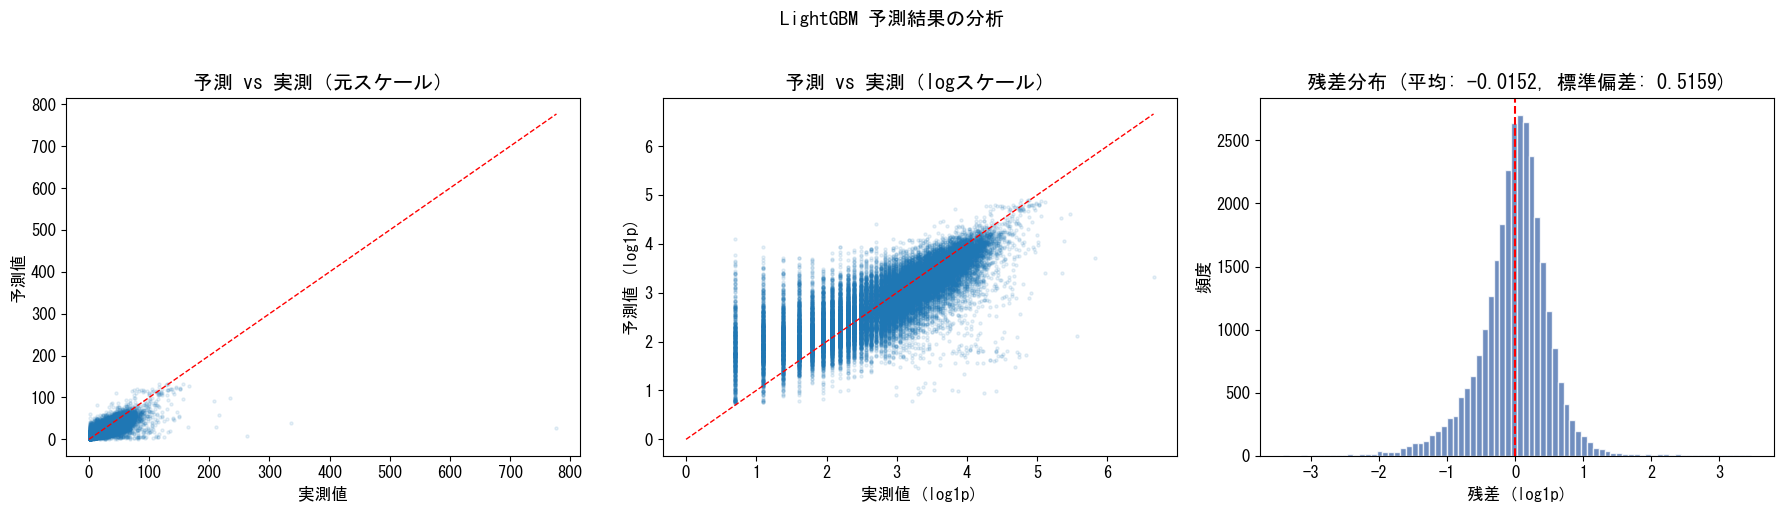

In [6]:
# 予測 vs 実測の散布図
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 散布図（元スケール）
axes[0].scatter(valid_df['visitors'], pred, alpha=0.1, s=5)
max_val = max(valid_df['visitors'].max(), pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1)
axes[0].set_xlabel('実測値')
axes[0].set_ylabel('予測値')
axes[0].set_title('予測 vs 実測（元スケール）')

# 散布図（logスケール）
axes[1].scatter(np.log1p(valid_df['visitors']), pred_log, alpha=0.1, s=5)
max_log = max(np.log1p(valid_df['visitors']).max(), pred_log.max())
axes[1].plot([0, max_log], [0, max_log], 'r--', linewidth=1)
axes[1].set_xlabel('実測値 (log1p)')
axes[1].set_ylabel('予測値 (log1p)')
axes[1].set_title('予測 vs 実測（logスケール）')

# 残差分布
residuals = np.log1p(valid_df['visitors']) - pred_log
axes[2].hist(residuals, bins=80, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_xlabel('残差 (log1p)')
axes[2].set_ylabel('頻度')
axes[2].set_title(f'残差分布 (平均: {residuals.mean():.4f}, 標準偏差: {residuals.std():.4f})')

plt.suptitle('LightGBM 予測結果の分析', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

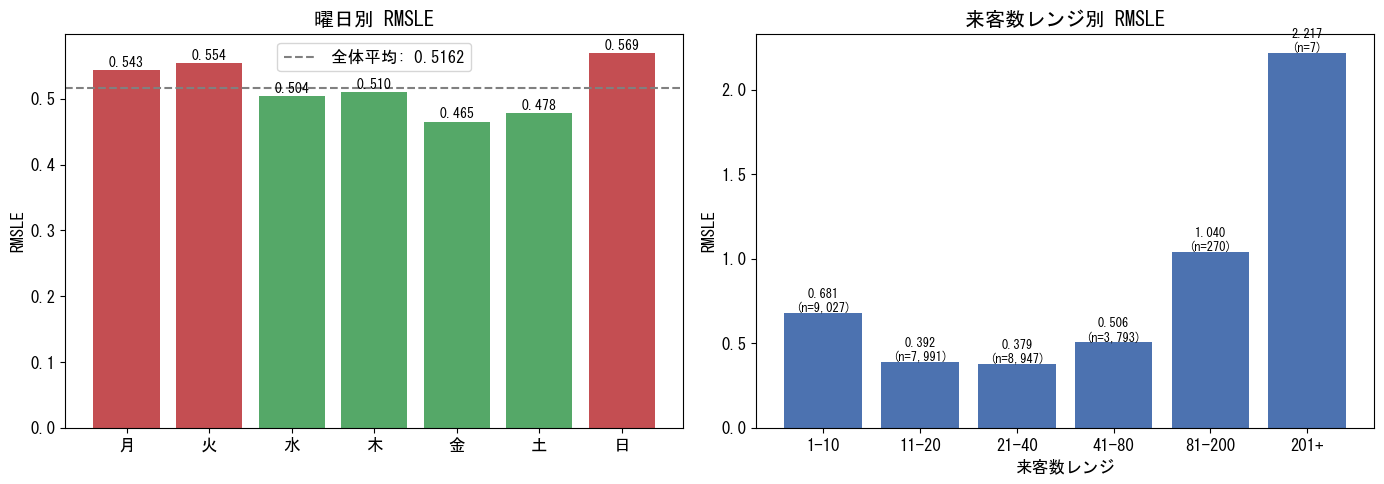

In [7]:
# セグメント別のスコア分析
valid_analysis = valid_df[['air_store_id', 'visit_date', 'visitors', 'dow', 'is_holiday']].copy()
valid_analysis['pred'] = pred

# 曜日別スコア
dow_names = ['月', '火', '水', '木', '金', '土', '日']
dow_scores = []
for d in range(7):
    mask = valid_analysis['dow'] == d
    s = rmsle(valid_analysis.loc[mask, 'visitors'], valid_analysis.loc[mask, 'pred'])
    dow_scores.append(s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#C44E52' if s > np.mean(dow_scores) else '#55A868' for s in dow_scores]
axes[0].bar(dow_names, dow_scores, color=colors)
axes[0].axhline(score_single, color='gray', linestyle='--', label=f'全体平均: {score_single:.4f}')
axes[0].set_ylabel('RMSLE')
axes[0].set_title('曜日別 RMSLE')
axes[0].legend()
for i, s in enumerate(dow_scores):
    axes[0].text(i, s + 0.005, f'{s:.3f}', ha='center', fontsize=10)

# 来客数レンジ別スコア
bins = [0, 10, 20, 40, 80, 200, 1000]
labels = ['1-10', '11-20', '21-40', '41-80', '81-200', '201+']
valid_analysis['visitor_range'] = pd.cut(valid_analysis['visitors'], bins=bins, labels=labels)
range_scores = []
for label in labels:
    mask = valid_analysis['visitor_range'] == label
    if mask.sum() > 0:
        s = rmsle(valid_analysis.loc[mask, 'visitors'], valid_analysis.loc[mask, 'pred'])
        range_scores.append((label, s, mask.sum()))

range_labels = [r[0] for r in range_scores]
range_vals = [r[1] for r in range_scores]
axes[1].bar(range_labels, range_vals, color='#4C72B0')
axes[1].set_ylabel('RMSLE')
axes[1].set_xlabel('来客数レンジ')
axes[1].set_title('来客数レンジ別 RMSLE')
for i, (label, s, n) in enumerate(range_scores):
    axes[1].text(i, s + 0.005, f'{s:.3f}\n(n={n:,})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 6. 特徴量重要度の分析

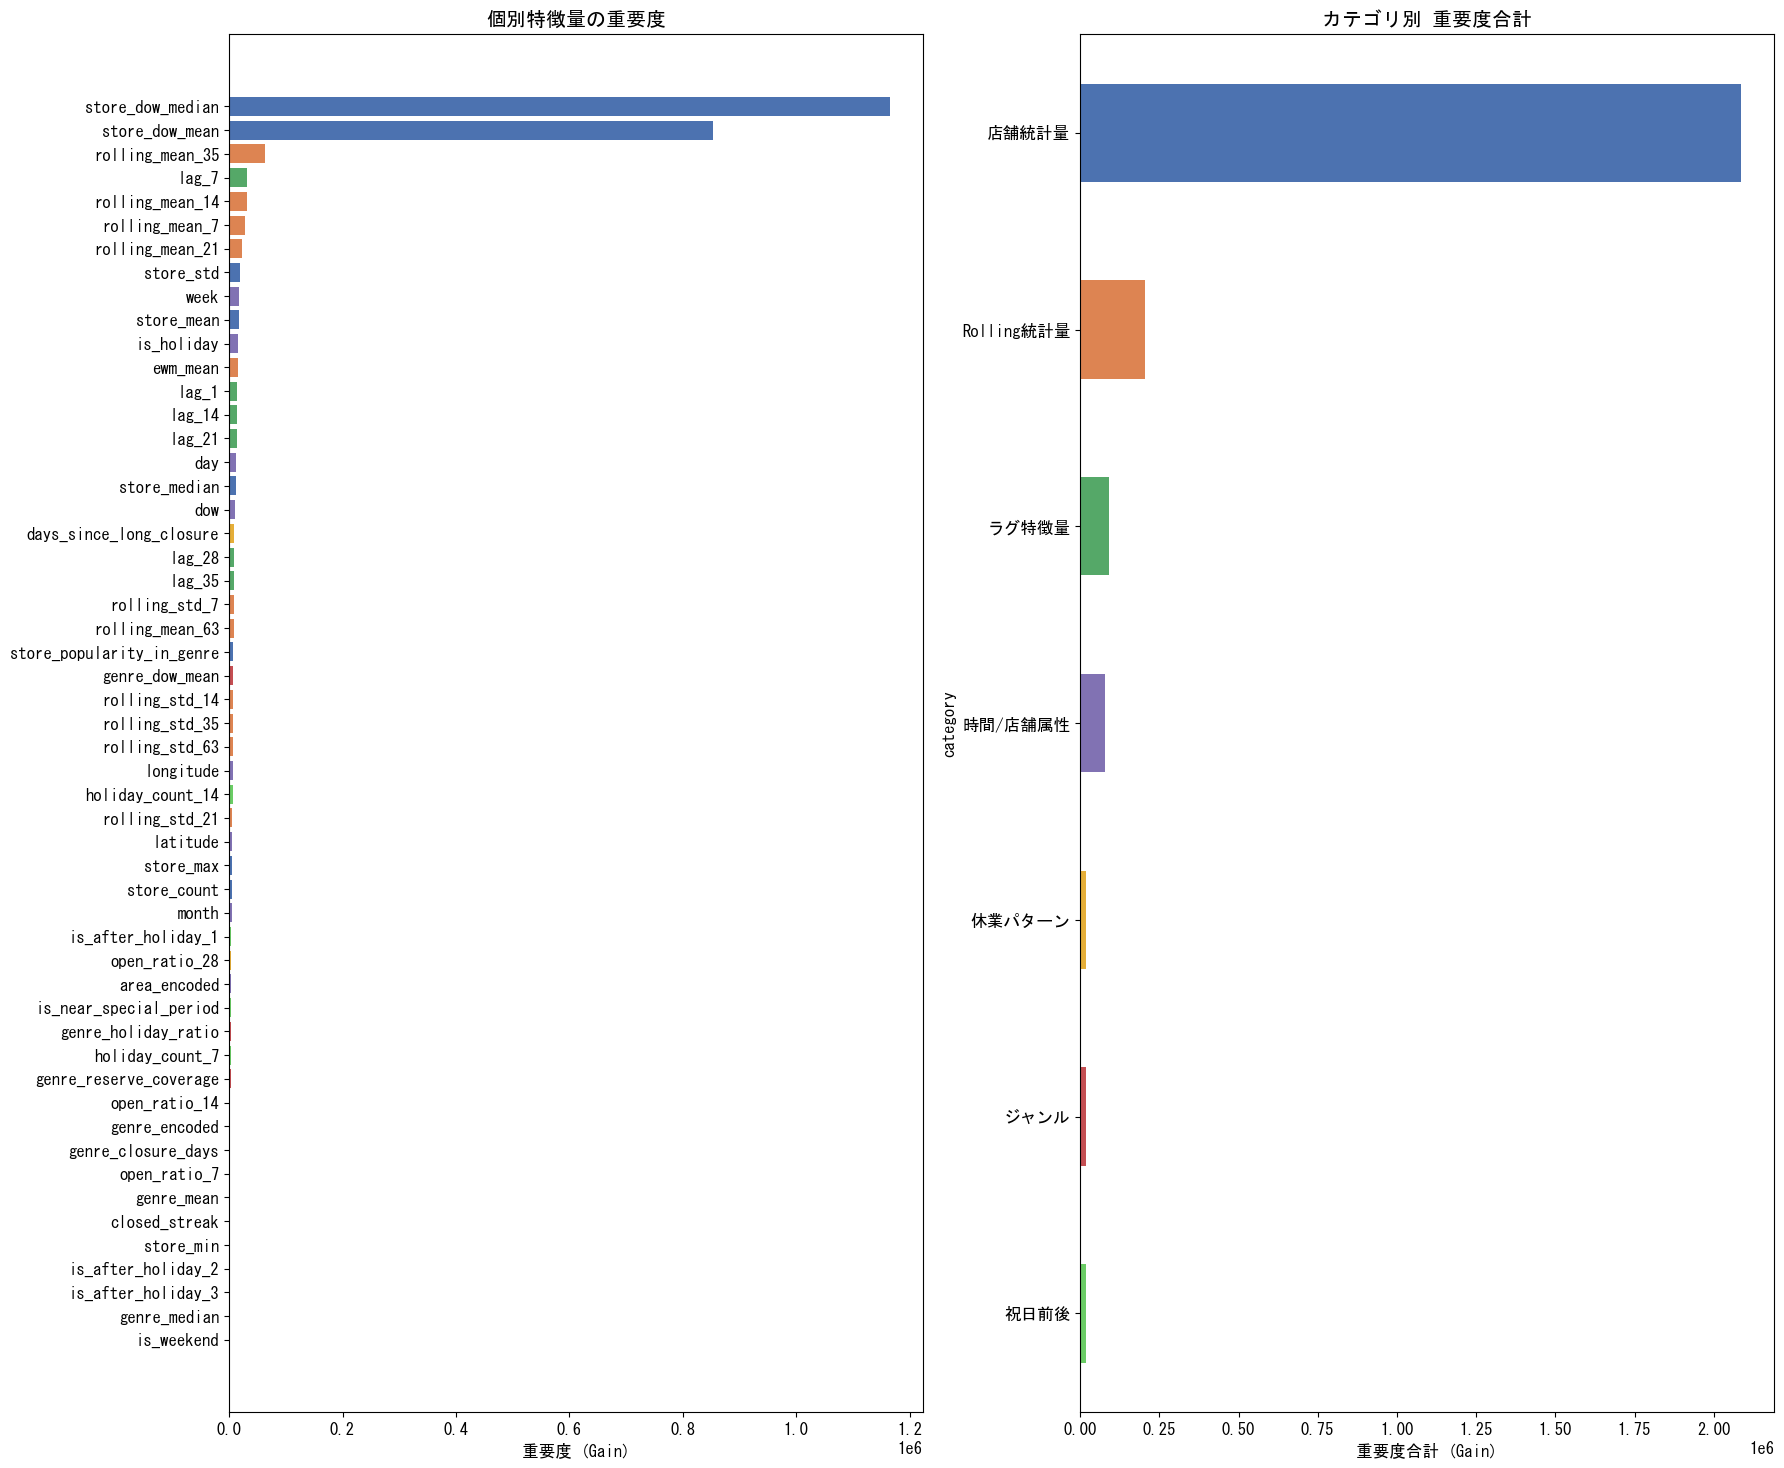


=== 上位10特徴量 ===
  [店舗統計量   ] store_dow_median: 1165092
  [店舗統計量   ] store_dow_mean: 853336
  [Rolling統計量] rolling_mean_35: 63534
  [ラグ特徴量   ] lag_7: 31552
  [Rolling統計量] rolling_mean_14: 31268
  [Rolling統計量] rolling_mean_7: 28486
  [Rolling統計量] rolling_mean_21: 23562
  [店舗統計量   ] store_std: 18767
  [時間/店舗属性 ] week: 17916
  [店舗統計量   ] store_mean: 16835


In [8]:
# 特徴量重要度（Gain）
importance = pd.DataFrame({
    'feature': all_features,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True)

def categorize_feature(name):
    if name.startswith('rolling_') or name.startswith('ewm_'):
        return 'Rolling統計量'
    elif name.startswith('lag_'):
        return 'ラグ特徴量'
    elif name.startswith(('open_ratio_', 'closed_streak', 'days_since_')):
        return '休業パターン'
    elif name.startswith(('is_after_holiday_', 'holiday_count_', 'is_near_special')):
        return '祝日前後'
    elif name.startswith('store_'):
        return '店舗統計量'
    elif name.startswith('genre_'):
        return 'ジャンル'
    else:
        return '時間/店舗属性'

importance['category'] = importance['feature'].apply(categorize_feature)

color_map = {
    'Rolling統計量': '#DD8452', 'ラグ特徴量': '#55A868',
    '店舗統計量': '#4C72B0', 'ジャンル': '#C44E52', '時間/店舗属性': '#8172B3',
    '休業パターン': '#E5AE38', '祝日前後': '#6ACC65'
}

fig, axes = plt.subplots(1, 2, figsize=(18, max(10, len(all_features) * 0.28)))

colors = importance['category'].map(color_map)
axes[0].barh(importance['feature'], importance['importance'], color=colors)
axes[0].set_xlabel('重要度 (Gain)')
axes[0].set_title('個別特徴量の重要度')

cat_imp = importance.groupby('category')['importance'].sum().sort_values()
cat_colors = [color_map.get(c, 'gray') for c in cat_imp.index]
cat_imp.plot(kind='barh', ax=axes[1], color=cat_colors)
axes[1].set_xlabel('重要度合計 (Gain)')
axes[1].set_title('カテゴリ別 重要度合計')

plt.tight_layout()
plt.show()

print('\n=== 上位10特徴量 ===')
for _, row in importance.tail(10).iloc[::-1].iterrows():
    print(f'  [{row["category"]:8s}] {row["feature"]}: {row["importance"]:.0f}')

---
## 7. 残差分析

予測が特に外れているケースを分析し、モデルの弱点を把握する。

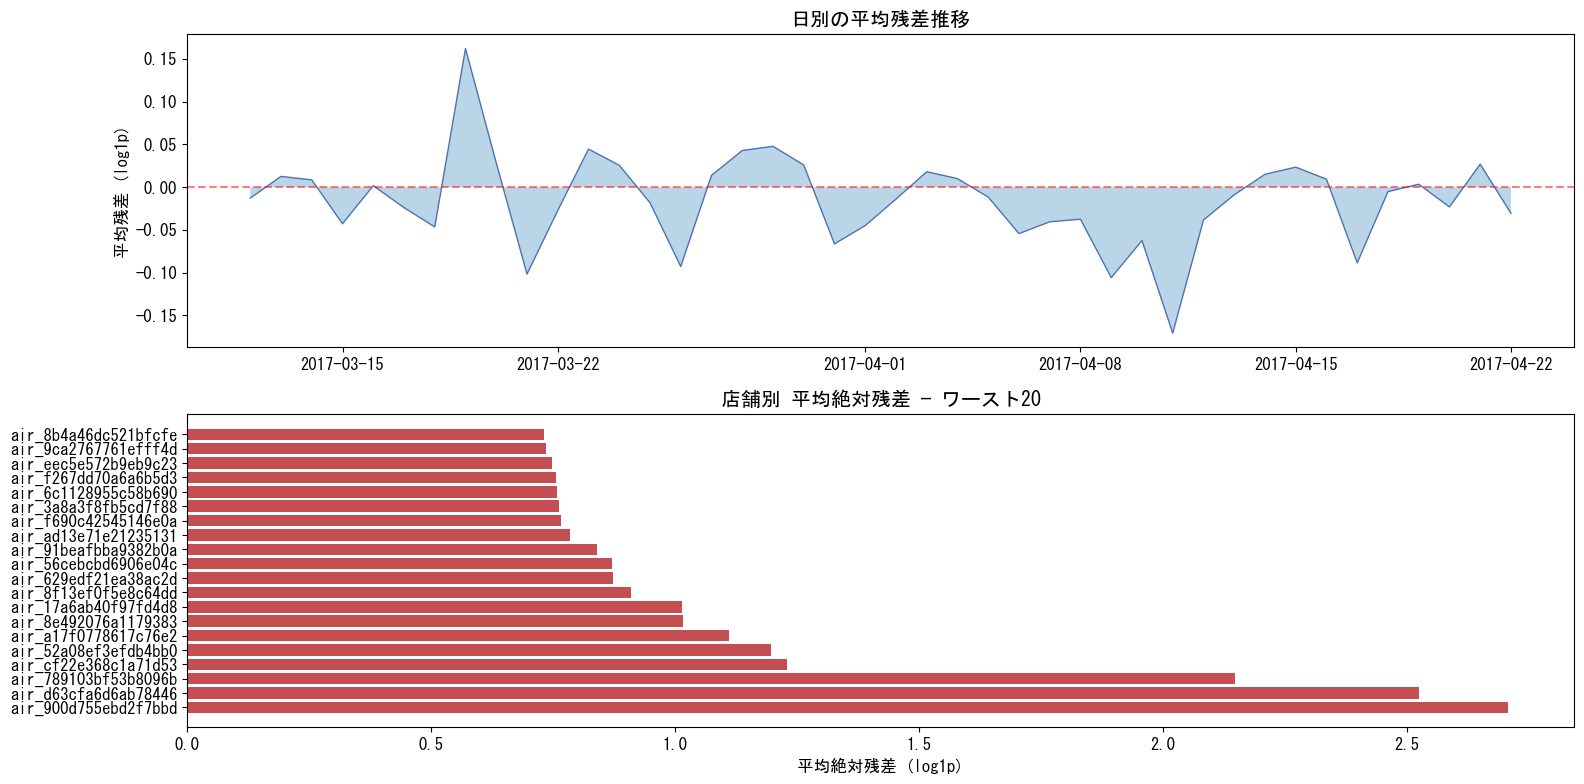


=== 大きな予測誤差（|残差| > 1.0）のケース ===
  件数: 1,774 / 30,035 (5.9%)
  祝日の割合: 2.1%（全体: 1.8%）
  曜日分布:
    月: 13.6%
    火: 17.6%
    水: 14.5%
    木: 14.4%
    金: 11.0%
    土: 12.3%
    日: 16.6%


In [9]:
# 残差の時系列推移
valid_analysis['residual'] = np.log1p(valid_analysis['visitors']) - pred_log
valid_analysis['abs_residual'] = valid_analysis['residual'].abs()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# 日別の平均残差
daily_residual = valid_analysis.groupby('visit_date')['residual'].mean()
axes[0].plot(daily_residual.index, daily_residual.values, color='#4C72B0', linewidth=1)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].fill_between(daily_residual.index, daily_residual.values, 0, alpha=0.3)
axes[0].set_ylabel('平均残差 (log1p)')
axes[0].set_title('日別の平均残差推移')

# 店舗別の平均絶対残差（上位20店舗）
store_mae = valid_analysis.groupby('air_store_id')['abs_residual'].mean().sort_values(ascending=False)
top20 = store_mae.head(20)
axes[1].barh([s[:20] for s in top20.index], top20.values, color='#C44E52')
axes[1].set_xlabel('平均絶対残差 (log1p)')
axes[1].set_title('店舗別 平均絶対残差 — ワースト20')

plt.tight_layout()
plt.show()

# 大きく外れた予測の分析
large_error = valid_analysis[valid_analysis['abs_residual'] > 1.0]
print(f'\n=== 大きな予測誤差（|残差| > 1.0）のケース ===')
print(f'  件数: {len(large_error):,} / {len(valid_analysis):,} ({len(large_error)/len(valid_analysis)*100:.1f}%)')
if len(large_error) > 0:
    print(f'  祝日の割合: {large_error["is_holiday"].mean()*100:.1f}%（全体: {valid_analysis["is_holiday"].mean()*100:.1f}%）')
    print(f'  曜日分布:')
    for d in range(7):
        pct = (large_error['dow'] == d).mean() * 100
        print(f'    {dow_names[d]}: {pct:.1f}%')

---
## 8. ハイパーパラメータチューニング（Optuna）

セクション3で設定した初期値をベースに、Optunaで主要パラメータを探索する。

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 50

def objective_lgb(trial):
    params = {
        'objective': 'regression', 'metric': 'rmse', 'verbose': -1,
        'random_state': SEED, 'n_jobs': -1,
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    
    # val_foldsベースのCV平均で最適化（Single Split過適合を防止）
    fold_scores = []
    for fold in val_folds:
        val_start = pd.Timestamp(fold['val_start'])
        val_end = pd.Timestamp(fold['val_end'])
        
        train_mask = full_df['visit_date'] < val_start
        valid_mask = (full_df['visit_date'] >= val_start) & (full_df['visit_date'] <= val_end)
        
        fold_train = full_df[train_mask]
        fold_valid = full_df[valid_mask]
        
        if len(fold_train) == 0 or len(fold_valid) == 0:
            continue
        
        dtr = lgb.Dataset(fold_train[all_features], label=np.log1p(fold_train['visitors']))
        dva = lgb.Dataset(fold_valid[all_features], label=np.log1p(fold_valid['visitors']), reference=dtr)
        
        m = lgb.train(params, dtr, num_boost_round=2000,
                      valid_sets=[dva], callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
        
        p = np.expm1(m.predict(fold_valid[all_features]))
        fold_scores.append(rmsle(fold_valid['visitors'], p))
    
    return np.mean(fold_scores) if fold_scores else float('inf')

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective_lgb, n_trials=N_TRIALS, show_progress_bar=True)

print(f'=== Optunaチューニング結果 ({N_TRIALS}試行, {len(val_folds)}フォールドCV) ===')
print(f'  デフォルト CV平均 RMSLE: {np.mean(cv_scores):.5f}')
print(f'  最適化後 CV平均 RMSLE:  {study.best_value:.5f}')
print(f'  改善幅: {np.mean(cv_scores) - study.best_value:+.5f}')
print(f'\n最適パラメータ:')
for k, v in study.best_params.items():
    print(f'  {k}: {v:.6f}' if isinstance(v, float) else f'  {k}: {v}')

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
# チューニング済みモデルで再学習・再予測
lgb_best_params = {**study.best_params, 'objective': 'regression', 'metric': 'rmse',
                   'verbose': -1, 'random_state': SEED, 'n_jobs': -1}

dtr = lgb.Dataset(X_tr_opt, label=y_tr_opt)
dva = lgb.Dataset(X_va_opt, label=np.log1p(y_va_raw_opt), reference=dtr)
model_tuned = lgb.train(lgb_best_params, dtr, num_boost_round=2000,
                        valid_sets=[dva], valid_names=['valid'],
                        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])

pred_log_tuned = model_tuned.predict(X_va_opt)
pred_tuned = np.expm1(pred_log_tuned)
score_tuned = rmsle(y_va_raw_opt, pred_tuned)
residuals_tuned = np.log1p(y_va_raw_opt.values) - pred_log_tuned

print(f'チューニング済みモデル: RMSLE={score_tuned:.5f} (best_iter={model_tuned.best_iteration})')
print(f'デフォルトモデル:       RMSLE={score_single:.5f}')
print(f'改善幅: {score_single - score_tuned:+.5f}')

---
## 9. まとめと次ステップ

In [ ]:
print('=== LightGBM モデル結果まとめ ===')
print(f'\n【スコア】')
print(f'  ルールベース（store×DOW中央値）: {baseline_rmsle:.5f}')
print(f'  LightGBM Single Split RMSLE: {score_single:.5f}')
print(f'  LightGBM CV平均 RMSLE: {np.mean(cv_scores):.5f} (+/- {np.std(cv_scores):.5f})')
print(f'  LightGBM Optuna CV平均: {study.best_value:.5f}')
print(f'  LightGBM Tuned Single: {score_tuned:.5f}')
print(f'\n【モデル設定】')
print(f'  Best iteration (default): {model.best_iteration}')
print(f'  Best iteration (tuned): {model_tuned.best_iteration}')
print(f'  特徴量数: {len(all_features)}')
print(f'\n【上位5特徴量】')
for _, row in importance.tail(5).iloc[::-1].iterrows():
    print(f'  {row["feature"]} ({row["category"]})')
print(f'\n→ LightGBMベースラインを確立。次のステップ（03-2）でXGBoostと比較する。')

In [ ]:
# 中間データの保存（チューニング済みモデルを保存）
import joblib

results_03_1 = {
    # デフォルトモデル結果
    'valid_pred': pred,
    'valid_pred_log': pred_log,
    'valid_actual': valid_df['visitors'].values,
    'score_single': score_single,
    'cv_scores': cv_scores,
    'cv_mean': np.mean(cv_scores),
    'cv_std': np.std(cv_scores),
    'feature_importance': importance,
    'params': lgb_params,
    'best_iteration': model.best_iteration,
    'residuals': residuals.values,
    # ルールベースベースライン
    'baseline_rmsle': baseline_rmsle,
    'baseline_pred': baseline_pred.values,
    'store_dow_median': store_dow_median,
    # チューニング済みモデル結果
    'tuned_pred': pred_tuned,
    'tuned_pred_log': pred_log_tuned,
    'tuned_score': score_tuned,
    'tuned_params': lgb_best_params,
    'tuned_best_iteration': model_tuned.best_iteration,
    'tuned_residuals': residuals_tuned,
    'optuna_best_params': study.best_params,
}

with open(INTERMEDIATE_DIR / '03-1_lgbm_results.pkl', 'wb') as f:
    pickle.dump(results_03_1, f)

joblib.dump(model_tuned, INTERMEDIATE_DIR / '03-1_lgbm_model.joblib')

print('中間データ保存完了:')
print(f'  結果: {INTERMEDIATE_DIR / "03-1_lgbm_results.pkl"}')
print(f'  モデル: {INTERMEDIATE_DIR / "03-1_lgbm_model.joblib"} (チューニング済み)')